# Skeleton-of-Thought

1. **Skeleton Stage**：拆解問題的主要框架或骨架。
2. **Point-expanding Stage**：進一步擴展每個骨架的具體細節。
將前一日的新聞資料依據 Skeleton Stage 拆解的每個判斷依據都做一次判斷隔日漲跌  
e.g. 20230104的新聞判斷漲跌後存在20230105  
儲存格式：  
20230105  
判斷依據1: 由20230104的新聞判斷為漲  
判斷依據2: 由20230104的新聞判斷為跌  
...  


檔案說明：  
存在 out_twii/sot  


In [63]:
import os
import json
import textwrap
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# print(llm.invoke("hello world"))
# print(llm.model_name)
# print(llm.model_kwargs)

# path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
# path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
symbol = "AAPL"
path_price = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/us/dataset/stocknet/price/raw/" + symbol
path_news = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/us/dataset/stocknet/tweet/preprocessed/" + symbol
path_out = "out_stocknet_GAsot/" + symbol

In [96]:
# 寫一個從第2014年開始的函數
def get_date_range(start_date, end_date):
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    date_list = []
    while start_date <= end_date:
        date_list.append(start_date.strftime("%Y-%m-%d"))
        start_date += relativedelta(days=1)
    return date_list

date_list = get_date_range("2014-01-01", "2015-12-31")
# print(date_list)

# # 讀取新聞
# for day in date_list:
#     if os.path.exists(path_news + "/" + day) == False:
#         continue
#     with open(path_news + "/" + day, 'r') as f:
#         news = f.read()
#         print(news)

# 讀取股價
price = pd.read_csv(path_price + ".csv")

# 抓特定時間範圍的股價
price = price[price['Date'].isin(date_list)]
print(price)
# 計算股價變化
# 計算當日開盤到收盤的股價變化
price["Movement_Percent"] = (price["Close"] - price["Open"]) / price["Open"]
price["Movement"] = np.where(price["Movement_Percent"] > 0, 1, 0)
print(price)
actual_date_list = price["Date"].tolist()
print(actual_date_list)

           Date        Open        High         Low       Close   Adj Close  \
333  2014-01-02   79.382858   79.575714   78.860001   79.018570   73.522530   
334  2014-01-03   78.980003   79.099998   77.204285   77.282860   71.907555   
335  2014-01-06   76.778572   78.114288   76.228569   77.704285   72.299644   
336  2014-01-07   77.760002   77.994286   76.845711   77.148575   71.782608   
337  2014-01-08   76.972855   77.937141   76.955711   77.637146   72.237190   
..          ...         ...         ...         ...         ...         ...   
832  2015-12-24  109.000000  109.000000  107.949997  108.029999  104.380112   
833  2015-12-28  107.589996  107.690002  106.180000  106.820000  103.210999   
834  2015-12-29  106.959999  109.430000  106.860001  108.739998  105.066116   
835  2015-12-30  108.580002  108.699997  107.180000  107.320000  103.694107   
836  2015-12-31  107.010002  107.029999  104.820000  105.260002  101.703697   

        Volume  
333   58671200  
334   98116900  


In [62]:
def print_news(date_list, count, stock_id, price, path_news):
   
    news_rise = ''
    news_fall = ''
    for i in range(count):
        
        price_date = date_list[i]
        news_date_temp = datetime.strptime(price_date, "%Y-%m-%d") - relativedelta(days=1)
        news_date = news_date_temp.strftime("%Y-%m-%d")
        
        rtn = price.loc[price['Date'] == price_date, 'Movement_Percent'].values[0]

        news_daily = ""
        # print(price_date)
        # print(rtn)
        with open(path_news + "/" + news_date, 'r') as f:
            news = f.read()
            # Split the news data into lines
            news_lines = news.strip().splitlines()
            # Process each news entry
            for line in news_lines:
                news_entry = json.loads(line)
                news_in = news_entry["text"]
                news_daily += " ".join(news_in)
                news_daily += "\n"
            # print(news_daily)


        if rtn > 0:
            # news += f"rtn: {round(rtn,5)}, {news_daily}\n"
            news_rise += f"{news_daily}\n"

        if rtn < 0:
            # news += f"rtn: {round(rtn,5)}, {news_daily}\n"
            news_fall += f"{news_daily}\n"


    return news_rise, news_fall


news_rise, news_fall = print_news(actual_date_list, 1, symbol, price, path_news)

print(
f"""

After the following news, {symbol}'s stock price rose the next day:
『{news_rise}』

After the following news, {symbol}'s stock price fell:
『{news_fall}』

Please compare the differences between the two sets of news for {symbol}.
List 20 possible reasons for the price increase and another 10 possible reasons for the price decrease.""")



After the following news, AAPL's stock price rose the next day:
『』

After the following news, AAPL's stock price fell:
『rt AT_USER summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - - URL
rt AT_USER summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - - URL
itv will boost apple URL $ aapl apple
iphone users are more intelligent than samsung , blackberry and htc owners , $ aapl $ bbry , URL
rt AT_USER summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - - URL
2013 wrap-up and trading set review - part iii URL $ aapl apple $ bp $ cnw $ csco $ csx $ cvx $ goog $ hpq $ ibm $ intc $ ngg
apple screwed up big time URL $ amzn $ aapl
rt AT_USER summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - - URL

』

Please compare the differences between the two sets o

# Skeleton Stage
建立骨架 Skeleton

In [97]:
# 定義策略元素字典，每個元素對應一個代號

# skeletons = {
skeletons = {
    "1": "App Store Revenue：Sales exceeding $10B",
    "2": "Strong Market Position：Dominance in smartphone penetration (41.2%).",
    "3": "Product Sales Momentum：High downloads.",
    "4": "Positive Analyst Targets：Target reinforces optimism.",
    "5": "Samsung Struggles：Competitor reports profit decline.",
    "6": "New Market Moves：Apple opens new store.",
    "7": "China Growth Potential：Expanding presence in Chinese channels.",
    "8": "Innovative Product Launches：Rumors about wireless charging iWatch.",
    "9": "Investor Confidence：Large institutional buy-ins observed.",
    "10": "Technological Leadership：Apple leads with app store revenue.",
    "11": "Bullish Technical Indicators：Stock broke key resistance levels.",
    "12": "Apple Pay Success：Growing adoption in the financial ecosystem.",
    "13": "Positive Earnings Speculation：Earnings anticipation boosts stock.",
    "14": "Holiday Sales Records：Strong performance in sales.",
    "15": "CEO Optimism：Statements projecting strong growth.",
    "16": "Industry Innovations：Expected disruptive products in tech.",
    "17": "New Retail Partnerships：Stronger retail distribution globally.",
    "18": "Stock Repurchase Program：Aggressive buybacks improve EPS.",
    "19": "M&A Rumors：Speculations of strategic acquisitions.",
    "20": "Global Expansion Plans：Focus on high-growth international markets.",
    "21": "Margin Concerns：Downgrade due to shrinking margins.",
    "22": "Competitor Pressure：Xiaomi and others challenging market share.",
    "23": "Leadership Skepticism：Criticism of Tim Cook's effectiveness.",
    "24": "Downgrade Sentiment：Analysts issue bearish outlook.",
    "25": "Technical Resistance：Stock fails to break resistance levels.",
    "26": "Valuation Worries：Overvaluation concerns resurface.",
    "27": "Supply Chain Issues：Rumors of manufacturing bottlenecks.",
    "28": "Global Market Fears：Broad market corrections impact sentiment.",
    "29": "Weak Start to Year：Wall Street opens year on a low note.",
    "30": "Regulatory Scrutiny：Potential risks from US monitors."
    
}



# Access by index using list of keys
key_list = list(skeletons.keys())
value_list = list(skeletons.values())

# Point-expanding Stage

In [ ]:
# stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
# path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
# st = datetime(2024, 4, 1)
# et = datetime(2024, 6, 30)

# # 讀取CSV檔案
# df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
# df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
# df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]

# for i in range(len(df_price_his)):
#     # 取得前一日日期和新聞標題
#     news_date = df_price_his.iloc[i]['日期'] - timedelta(days=1)
#     text_news = "權值股的熱門新聞標題"
#     for j, stock_id in enumerate(stock_ids):
#         path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
#         with open(path_news_file, 'r', encoding='utf-8') as f:
#             news_data = json.load(f)
#             text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
#     print(text_news)

#             ("system", "你是一個厲害的金融領域專家"),
#             ("human",
# f"""
# 這是新聞標題{text_news}
# 如果有符合{skeleton}所表示的利多請回答yes，如果是利空則回答no，如果無法判斷則回答unknown。

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no/#unknown 請盡量不要回答unknown
# 你的理由: **非常簡短**的用 1∼2 句話寫出來！
# """)

In [105]:
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def point_expanting(llm, date_list, stock_id, price, path_news):
    output_data = {}
    
    for i in range(len(date_list)):
        price_date = date_list[i]
        news_date_temp = datetime.strptime(price_date, "%Y-%m-%d") - relativedelta(days=1)
        news_date = news_date_temp.strftime("%Y-%m-%d")

        news_daily = ""
        if os.path.exists(path_news + "/" + news_date) == False:
            continue
        with open(path_news + "/" + news_date, 'r') as f:
            news = f.read()
            # Split the news data into lines
            news_lines = news.strip().splitlines()
            # Process each news entry
            for line in news_lines:
                news_entry = json.loads(line)
                news_in = news_entry["text"]
                news_daily += " ".join(news_in)
                news_daily += "\n"

        batch = []
        for skeleton in value_list:
            messages = [
                ("human",
                f"""
                This is a news headline: {news_daily}  
                If it aligns with the positives indicated by {skeleton}, answer **yes**.  
                If it aligns with the negatives, answer **no**.  
                If it cannot be determined, answer **unknown**.  

                Respond in the following format, considering all the news collectively to provide **one single answer**:  

                **Result**: #yes / #no / #unknown (try to avoid answering unknown)  
                **Reason**: Provide a **very brief** explanation in 1-2 sentences.
                """)
            ]
            batch.append(messages)
        res = llm.batch(batch)

        skeleton_res = {}
        for i in range(len(res)):
            sig = 0
            sig_str = res[i].content.split("Reason")[0]
            if "unknown" in sig_str:
                sig = 0
            elif "yes" in sig_str:
                sig = 1
            elif "no" in sig_str:
                sig = -1

            skeleton_res[key_list[i]] = {
                "response" : res[i].content,
                "sig" : sig,
                "token": res[i].usage_metadata
            }
        
        output_data[price_date] = {
            "skeleton": skeleton_res,
        }

    # 將所有輸出數據寫入到同一個dictioanry中
    data = {
        "model": llm.model_name,
        "temperature": llm.temperature,
        "stock_id": stock_id,
        "output_data": output_data,
    }
    
    return data

In [122]:
# fix
# with open(f"{path_out}/expand.json", 'r') as f:
#     data = json.load(f)
#     print(data["output_data"]["2014-01-02"])

# for date_str in actual_date_list:

#     if date_str not in data["output_data"]:
#         continue

#     for key in data["output_data"][date_str]["skeleton"]:


#         sig = 0
#         sig_str = data["output_data"][date_str]["skeleton"][key]["response"].split("Reason")[0]
#         if "unknown" in sig_str:
#             sig = 0
#         elif "yes" in sig_str:
#             sig = 1
#         elif "no" in sig_str:
#             sig = -1
#         data["output_data"][date_str]["skeleton"][key]["sig"] = sig


# with open(f"{path_out}/expand2.json", 'w') as f:
#     json.dump(data, f, indent=4)

In [106]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")
    return out_file

## generate content

In [104]:
data = point_expanting(llm, actual_date_list, symbol, price, path_news)
save_data(f"{path_out}/", data)


已儲存至out_stocknet_GAsot/AAPL/1.json


'out_stocknet_GAsot/AAPL/1.json'

合併兩段不同日期的檔案

In [ ]:
def merge_data(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f:
        data1 = json.load(f)
    with open(path2, 'r', encoding='utf-8') as f:
        data2 = json.load(f)
    
    data1['output_data'].update(data2['output_data'])
    return data1

# 輸出合併後的檔案
data3 = merge_data(path_out + '4.json', path_out + '3.json')
save_data(path_out, data3)


# GA

## 評分

In [123]:
import pandas as pd
import json
import os

def eval(individual, stock_id, price, data):
    # print(data)
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    ttl_count = 0

    for date_str, value in data.items():
        ttl_count += 1
        # print(date_str)
        # print(value)
        
        sigs = []
        sig = 0
        for i in range(len(individual)):

            if individual[i] == 1:
                # print(value['skeleton'][f'E{str(i+1)}']['sig'])
                sigs.append(value['skeleton'][f'{str(i+1)}']['sig'])

            
        # 移除 sig 為 0 的元素
        sigs = list(filter(lambda a: a != 0, sigs))

        if len(sigs) > 0:
            # Count the frequency of each element
            count = Counter(sigs)

            # Get the maximum frequency
            max_count = max(count.values())

            # Get all elements with the maximum frequency
            most_frequent = [k for k, v in count.items() if v == max_count]

            # If there is a tie, set sig to 0; otherwise, set it to the most frequent element
            if len(most_frequent) > 1:
                sig = 0
            else:
                sig = most_frequent[0]

        rtn = price.loc[price['Date'] == date_str, 'Movement_Percent'].values[0]


        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count' : tp + fp + tn + fn,
        'ttl_count' : ttl_count,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
    }

    return result

## GA Training
遺傳演算法

In [125]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2014, 1, 1)
end_day = datetime(2015, 6, 30)
out_folder = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}2"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'

# 讀取日期範圍內的資料
with open(f"{path_out}/expand2.json", 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value

In [126]:
print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    # print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    result = eval(individual, symbol, price, data_in_datarange)
    score = result['accuracy']
    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")

    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.005):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.randint(0, 1)
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(skeletons, population_size=20, generations=70):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(skeletons))
    else:
        current_population = generate_population(population_size, len(skeletons))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.005))
            children.append(mutate(child2, 0.005))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 100000:
            print("Paused")
            break

    return best_individual

# 執行
best_individual = genetic_algorithm(skeletons)
print()
print(f"Best elements: {best_individual}")
print(individual_score)

Start, ask_count: 0 individual_score: {} 第一次跑的話請確認state是空的
Generation 1
selection
crossover
Best fitness = 0.5100864553314121
Best individual: [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0]

Generation 2
selection
crossover
Best fitness = 0.5072463768115942
Best individual: [0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Generation 3
selection
crossover
Best fitness = 0.5057142857142857
Best individual: [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1]

Generation 4
selection
crossover
Best fitness = 0.5072046109510087
Best individual: [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]

Generation 5
selection
crossover
Best fitness = 0.5072046109510087
Best individual: [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]

Generation 6
selection
crossover
Best fitness = 0.50720461095

## GA Testing
結果整理

In [140]:
import json

def print_out(result, state_str , st, et):

        print(f"{state_str} from {st} to {et}")

        print(f'''tp:{result["tp"]}, fp:{result["fp"]}, tn:{result["tn"]}, fn:{result["fn"]}, Available ask:[{result["avail_count"]}/{result["ttl_count"]}],
Accuracy : {round(result["accuracy"],3) }, Expected Value : {round(result["ev"], 7)},
Precision : {round(result["precision"],5)}, Precision Expected Value : {round(result["precision_ev"], 7)},
Recall : {round(result["recall"],5)}''')  

# individual = [random.randint(0, 1) for _ in range(48)]
individual = [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1]
#[1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
# individual = best_individual

# Train
start_day = datetime(2014, 1, 1)
end_day = datetime(2015, 6, 30)

with open(f"{path_out}/expand2.json", 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)

data_in_daterange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_daterange[date_str] = value
        
result = eval(individual, symbol, price, data_in_daterange)
print_out(result, "Train", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))
print()

# Test
start_day = datetime(2015, 7, 1)
end_day = datetime(2015, 12, 31)
data_in_daterange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_daterange[date_str] = value
# print(data_in_daterange)
result = eval(individual, symbol, price, data_in_daterange)
# print(result)
print_out(result, "Test", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))

Train from 2014-01-01 to 2015-06-30
tp:124, fp:126, tn:54, fn:44, Available ask:[348/358],
Accuracy : 0.511, Expected Value : -0.0002612,
Precision : 0.496, Precision Expected Value : -0.0003651,
Recall : 0.7381

Test from 2015-07-01 to 2015-12-31
tp:35, fp:33, tn:21, fn:27, Available ask:[116/125],
Accuracy : 0.483, Expected Value : -0.0014302,
Precision : 0.51471, Precision Expected Value : -0.00153,
Recall : 0.56452


# DEMO

## 作圖
使用 Best so far

out_stock/GA_sot_4omini//2454/20231001_202406302/generation_results.json


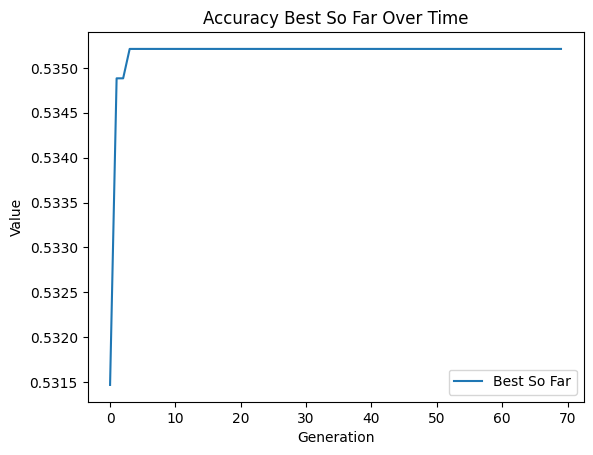

In [265]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# # 設定要顯示的最大代數
# max_generations = 50
# path_file = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}_15pro/"
# path_file = f"{path_out}{stock_id}/20231001_202406302_1/"

print(results_file)
with open(results_file, 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):

        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
# plt.plot(accs, label='Accuracy')
plt.plot(best_so_far, label='Best So Far')

plt.title('Accuracy Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  #


## 輸出判斷依據

In [153]:
# individual = [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
individual = best_individual
for i in range(len(individual)):
    if individual[i] == 1:
        print(value_list[i])

股價波動率: 股價的波動幅度能夠顯示市場對企業的短期反應和投資風險。
財報發佈: 公司定期公佈的財務報告可以反映出企業的經營狀況，對股價有顯著影響。
價格移動平均線: 平滑短期價格波動，幫助判斷股票的中長期趨勢。
公司內部管理調整: 內部管理的調整會影響企業的運營效率和員工士氣。
外匯匯率波動: 外匯匯率變動對國際企業的財務表現和市場評估產生直接影響。
競爭者動作: 競爭對手的市場策略或行為變化可能直接影響公司股價表現。
業內消息與謠言: 業內消息或謠言可能會影響市場對企業的認知，進而影響股價。
國際經濟事件影響: 全球性經濟事件如貿易戰或金融危機，會影響國際企業的表現。
股東回報政策: 穩定的股東回報政策能增加投資者的持股意願，推動股價穩定上升。
銷售數據公佈: 銷售數據能反映公司產品需求狀況，對未來收益具有預示作用。
市場需求波動: 市場對公司產品或服務的需求波動會直接影響其業績和股價表現。
成本控制措施: 良好的成本控制可以提升利潤率，從而對股價有積極影響。
競爭對手行為分析: 競爭對手的產品定價、行銷策略等變動會改變公司競爭格局。
客戶需求變化: 客戶需求的快速變化會對公司產品策略和市場反應產生影響。
價格調整策略: 公司的價格調整策略會影響其產品市場定位，從而影響銷售和收益。
預測性財務數據: 預期的財務數據公佈可能會影響市場預期和股票交易活動。
新產品推出時間點: 新產品推出的時間和效果會影響市場對企業未來增長的信心。
股息分配調整: 股息政策的調整會影響投資者的投資決策和市場對公司前景的看法。
投資者信心波動: 投資者對公司未來表現的信心波動會直接反映在股價的波動上。
財務風險評估: 企業財務狀況的風險評估會影響投資者的持股意願和公司股價。
合作夥伴變動: 與合作夥伴的關係變化會影響公司的市場策略和業務發展。
品牌推廣活動: 品牌推廣能提升公司產品的市場認知度，促進銷售和股價表現。
財務報表修正: 財務報表的修正可能反映出之前數據的誤差，影響市場信心。
行業趨勢變化: 行業趨勢的變化會影響公司未來的戰略和市場定位。


## 計算使用的費用

In [196]:
# with open(path_out + '/2.json', 'r') as f:
#     content = f.read().strip()
#     data_points = json.loads(content)
# ske = data_points["output_data"]

# # print(ske) 
# print(len(ske))
# # Initialize counters
# total_input_tokens = 0
# total_output_tokens = 0
# total_tokens = 0

# # Loop through each date and each element within skeleton
# for date, date_data in ske.items():
#     for element, element_data in date_data["skeleton"].items():
#         total_input_tokens += element_data["token"]["input_tokens"]
#         total_output_tokens += element_data["token"]["output_tokens"]
#         total_tokens += element_data["token"]["total_tokens"]

# print("Total input tokens:", total_input_tokens)
# print("Total output tokens:", total_output_tokens)
# print("Total tokens:", total_tokens)


# print(f'預估費用 {(total_input_tokens/1000000)*0.15 + (total_output_tokens/1000000)*0.6} USD')